In [ ]:
from google.colab import drive
drive.mount('/content/drive')

unzip:  cannot find or open /content/drive/MyDrive/archive.zip, /content/drive/MyDrive/archive.zip.zip or /content/drive/MyDrive/archive.zip.ZIP.


In [ ]:
!unzip /content/drive/MyDrive/archive.zip
!mkdir data
!mkdir models
!mv /content/CUB_200_2011 /content/data/

In [15]:
import os 
import csv

In [ ]:
data_folder = "/content/data/CUB_200_2011"

In [17]:
train_test_split_file = os.path.join(data_folder, "train_test_split.txt")
image_folder = os.path.join(data_folder, "images")
images_file = os.path.join(data_folder, "images.txt")
bounding_boxes_file = os.path.join(data_folder, "bounding_boxes.txt")

In [18]:
csv_train_rows = []
csv_test_rows = []

with open(images_file, 'r') as images_f, \
    open(train_test_split_file, 'r') as split_f, \
    open(bounding_boxes_file, 'r') as bbox_f:
        
        image_filenames = images_f.readlines()
        split_lines = split_f.readlines()
        bbox_lines = bbox_f.readlines()

In [ ]:
with open(f'{data_folder}/classes.txt', 'r') as f:
    classes = f.readlines()
    classes = [line.strip().split()[1].split('.')[-1] for line in classes]

class_2_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
class_2_idx

{'Black_footed_Albatross': 0,
 'Laysan_Albatross': 1,
 'Sooty_Albatross': 2,
 'Groove_billed_Ani': 3,
 'Crested_Auklet': 4,
 'Least_Auklet': 5,
 'Parakeet_Auklet': 6,
 'Rhinoceros_Auklet': 7,
 'Brewer_Blackbird': 8,
 'Red_winged_Blackbird': 9,
 'Rusty_Blackbird': 10,
 'Yellow_headed_Blackbird': 11,
 'Bobolink': 12,
 'Indigo_Bunting': 13,
 'Lazuli_Bunting': 14,
 'Painted_Bunting': 15,
 'Cardinal': 16,
 'Spotted_Catbird': 17,
 'Gray_Catbird': 18,
 'Yellow_breasted_Chat': 19,
 'Eastern_Towhee': 20,
 'Chuck_will_Widow': 21,
 'Brandt_Cormorant': 22,
 'Red_faced_Cormorant': 23,
 'Pelagic_Cormorant': 24,
 'Bronzed_Cowbird': 25,
 'Shiny_Cowbird': 26,
 'Brown_Creeper': 27,
 'American_Crow': 28,
 'Fish_Crow': 29,
 'Black_billed_Cuckoo': 30,
 'Mangrove_Cuckoo': 31,
 'Yellow_billed_Cuckoo': 32,
 'Gray_crowned_Rosy_Finch': 33,
 'Purple_Finch': 34,
 'Northern_Flicker': 35,
 'Acadian_Flycatcher': 36,
 'Great_Crested_Flycatcher': 37,
 'Least_Flycatcher': 38,
 'Olive_sided_Flycatcher': 39,
 'Scissor_ta

In [ ]:
# get 50 first classes

stop_line = 2889

for img_line, split_line, bbox_line in zip(image_filenames[:stop_line], split_lines[:stop_line], bbox_lines[:stop_line]):
    img_id, img_path = img_line.strip().split()
    _, is_train = split_line.strip().split()
    _, x, y, w, h = bbox_line.strip().split()
    
    image_path = str(os.path.join(image_folder, img_path))
    image_class = img_path.strip().split()[-1].split('/')[0].split('.')[-1]
    row_data = {
        'image_id': img_id,
        'image_path': os.path.join(image_folder, img_path),
        'bbox_x': float(x),
        'bbox_y': float(y),
        'bbox_w': float(w),
        'bbox_h': float(h),
        'class_idx': class_2_idx[image_class],
    }
    csv_train_rows.append(row_data) if is_train == '1' else csv_test_rows.append(row_data)
    
fieldnames = ['image_id', 'image_path', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'class_idx']
with open('image_data_train.csv', 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    for row in csv_train_rows:
        writer.writerow(row)
        
with open('image_data_test.csv', 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    for row in csv_test_rows:
        writer.writerow(row)

Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_footed_Albatross
Black_foote

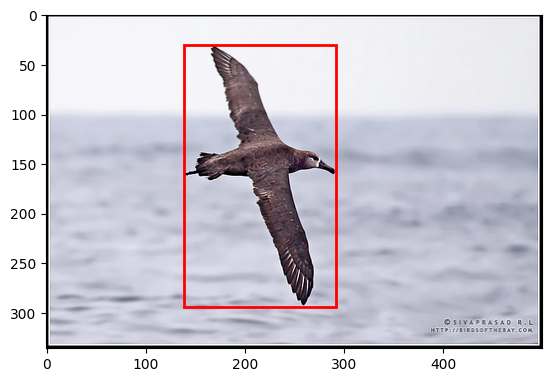

In [22]:
import matplotlib.pyplot as plt
example_row = csv_train_rows[0]
image = plt.imread(example_row['image_path'])
x, y, w, h = example_row['bbox_x'], example_row['bbox_y'], example_row['bbox_w'], example_row['bbox_h']
fig, ax = plt.subplots(1)
ax.imshow(image)
rect = plt.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.show()